## 08-06-2026 DATA VISUALIZATION
Imagine thousands of rows of data in a table. Reading raw numbers makes it hard to spot trends, compare values, find patterns, detect outliers, or decide quickly. A graph shows the trend instantly.

Pandas has a built in `.plot()` method that sits on top of matplotlib. So instead of writing matplotlib code by hand, I call `.plot()` straight off a DataFrame or a Series and pandas wires up the chart for me. The default is a line plot, and I switch the chart type with `kind=` or the shortcut `.plot.<type>()`.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(7)   # seed so the random numbers are the same every run

### Sample Data, Random Walk
Before plotting I need data. I create two objects:

- a DataFrame `df` (a 2D table) with one column of random numbers
- a Series `ts` (a single 1D column) of random numbers

Both are indexed by dates using `pd.date_range`, which generates a list of consecutive daily dates. `randn` gives random numbers from a normal distribution (centered on 0).

On their own these are just noise. I then apply `cumsum()` (cumulative sum), which replaces each value with the running total of everything up to that point. That turns random noise into a random walk: a line that drifts and wanders instead of staying flat around zero. A random walk gives a nice realistic looking trend to plot.

In [2]:
# DataFrame (table) and Series (single column), both indexed by 1000 daily dates
from numpy.random import randn
df = pd.DataFrame(randn(1000), index=pd.date_range('2019-06-07', periods=1000), columns=['value'])
ts = pd.Series(randn(1000), index=pd.date_range('2019-06-07', periods=1000))
df.head()

,value
2019-06-07,1.690526
2019-06-08,-0.465937
2019-06-09,0.032820
2019-06-10,0.407516
2019-06-11,-0.788923


In [3]:
# cumsum() - running total. Converts random noise into a random walk
df['value'] = df['value'].cumsum()
ts = ts.cumsum()
df.head()

,value
2019-06-07,1.690526
2019-06-08,1.224588
2019-06-09,1.257408
2019-06-10,1.664925
2019-06-11,0.876002


In [4]:
# type() - confirm the object types. df is a DataFrame, ts is a Series
type(df), type(ts)

(pandas.DataFrame, pandas.Series)

### Line Plots
A line plot connects data points in order with a line. It is the best choice for data that has an order, especially time series, because the line shows how the value moves over time.

`.plot()` with no arguments gives a line plot by default. There are three ways to draw the same line, and they are worth knowing because each comes up in different code:

- `ts.plot()` is the pandas way. Cleanest, and it labels the x axis with the dates automatically.
- `plt.plot(ts)` is the raw matplotlib way. More manual but more control.
- `df.plot()` plots every column of the DataFrame as its own line on the same axes.

`figsize=(width, height)` sets the size of the figure in inches. `plt.show()` displays the chart and stops matplotlib from printing the axes object text above it.

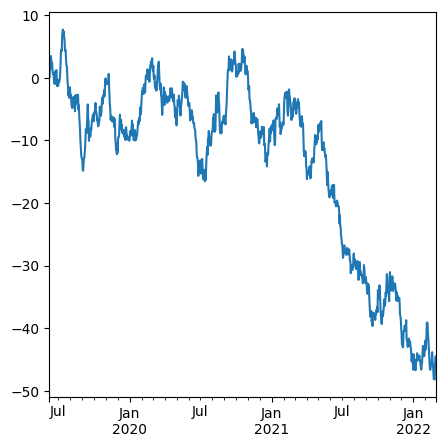

In [5]:
# plot() - default line plot. figsize sets the size in inches
ts.plot(figsize=(5, 5))
plt.show()

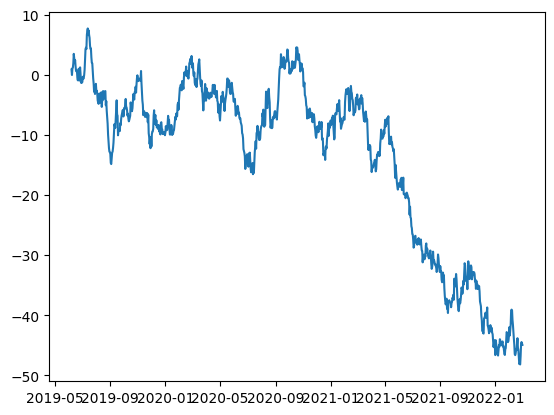

In [6]:
# plt.plot() - the raw matplotlib way, same data
plt.plot(ts)
plt.show()

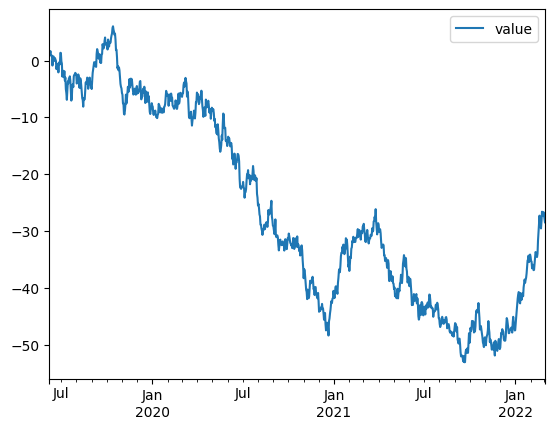

In [7]:
# df.plot() - plots every column of the DataFrame as a line
df.plot()
plt.show()

### Using a Built in Dataset, Iris
seaborn ships sample datasets so I do not have to find my own. `load_dataset('iris')` loads the classic iris flower dataset: 150 flowers from 3 species (setosa, versicolor, virginica), with 4 measurements each (sepal length, sepal width, petal length, petal width).

When I call `.plot()` on the whole DataFrame, pandas draws one line per numeric column. The x axis is the row number (0 to 149) and the y axis is the measurement value, so I can see how the four measurements vary across the flowers.

`.plot()` returns the axes object, usually called `ax`. I grab it so I can set the title and the axis labels with `set_xlabel` and `set_ylabel`. Anything matplotlib can do to an axes, I can do through `ax`.

In [8]:
# load_dataset() - seaborn sample data. iris = 150 flowers, 4 measurements + species
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


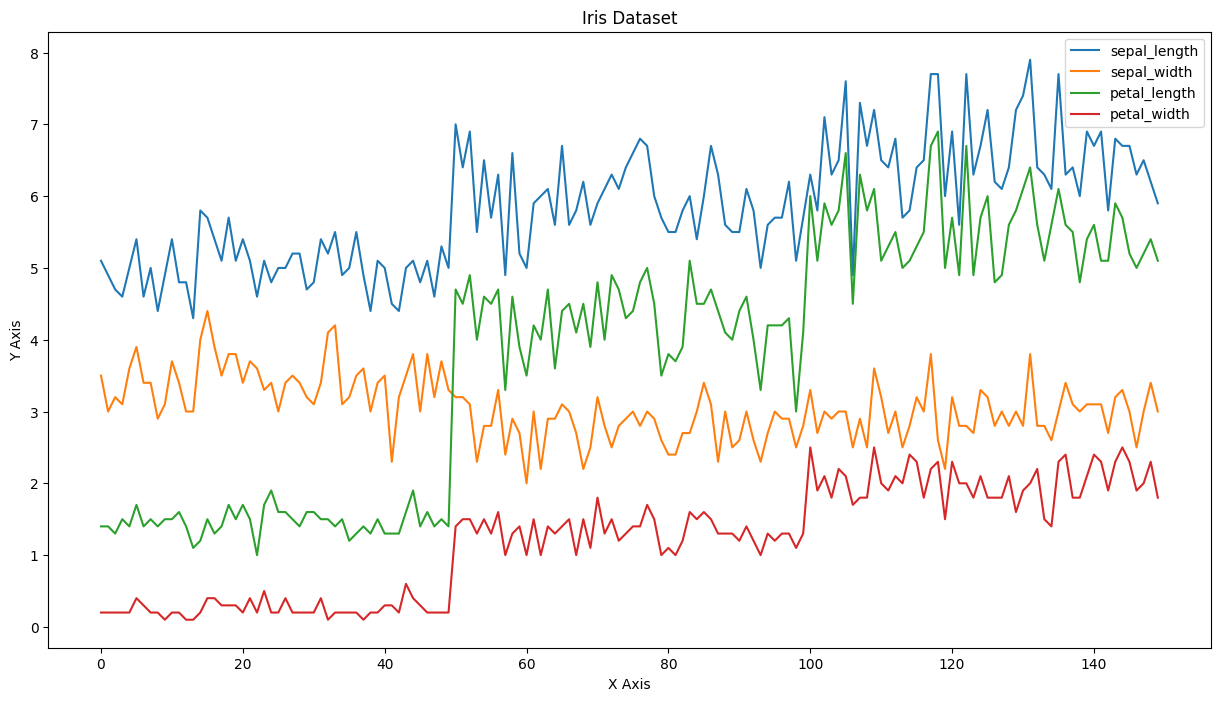

In [9]:
# plot returns the axes (ax). Use it to set the title and axis labels
ax = iris.plot(figsize=(15, 8), title='Iris Dataset')
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
plt.show()

### Bar Plots
A bar plot uses the height (or length) of bars to compare values across categories. Use it when the x axis is categories rather than a continuous order.

- `kind='bar'` gives vertical bars
- `.plot.barh()` gives horizontal bars, useful when category labels are long
- plotting a single row with `df_iris.iloc[0]` makes one bar per column, which is a clean way to compare the 4 measurements of one flower

`iloc[0]` selects the first row by position. `drop(['species'], axis=1)` removes the species text column so only the numeric measurements remain (`axis=1` means column, `axis=0` means row).

In [10]:
# drop() - remove a column (axis=1). Keep only the numeric measurements
df_iris = iris.drop(['species'], axis=1)
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


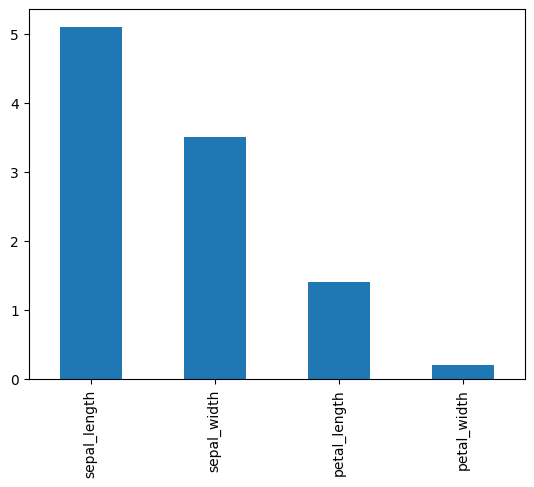

In [11]:
# kind='bar' - vertical bars. iloc[0] is the first flower, one bar per measurement
df_iris.iloc[0].plot(kind='bar')
plt.show()

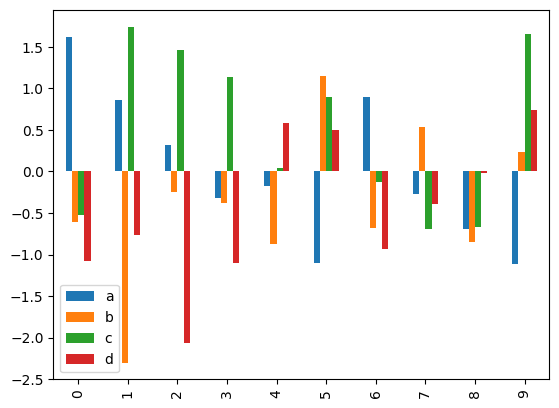

In [12]:
# grouped bars - each row becomes a cluster of bars (one per column)
np.random.seed(1)
bars = pd.DataFrame(randn(10, 4), columns=['a', 'b', 'c', 'd'])
bars.plot.bar()
plt.show()

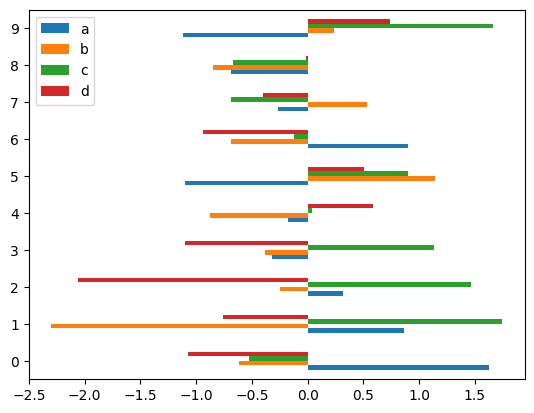

In [13]:
# barh - horizontal bars
bars.plot.barh()
plt.show()

### Histograms
A histogram shows the distribution of a single numeric variable. It splits the value range into equal buckets called bins and counts how many values fall in each bin. The shape tells me where values cluster, whether the data is skewed, and where outliers sit.

Key arguments:
- `bins=` sets the number of buckets. Too few hides detail, too many makes it noisy.
- `stacked=True` stacks the columns on top of each other instead of overlapping them.
- `orientation='horizontal'` flips the bars sideways.

`.diff()` takes the difference between each value and the one before it. Plotting a histogram of the diffs shows how big the step to step changes are, which is a different question from the raw distribution.

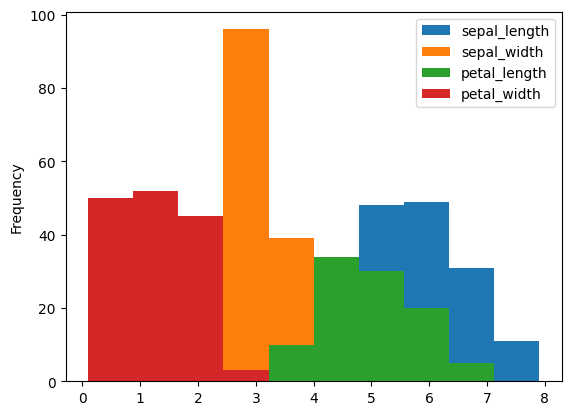

In [14]:
# hist - buckets values into bins to show the distribution shape
iris.plot(kind='hist')
plt.show()

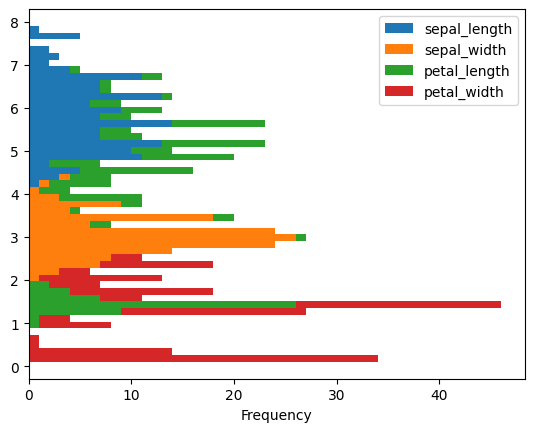

In [15]:
# stacked + bins + orientation - stack the columns, 50 bins, drawn sideways
iris.plot(kind='hist', stacked=True, bins=50, orientation='horizontal')
plt.show()

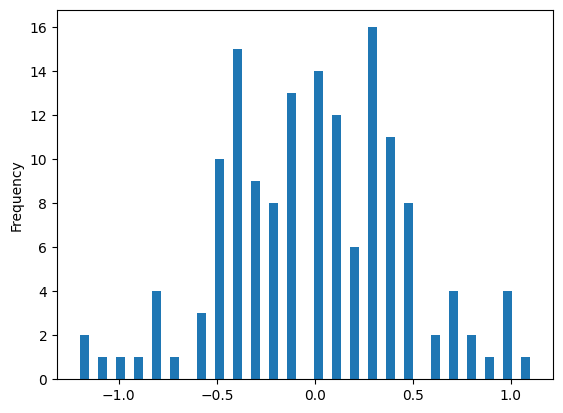

In [16]:
# diff() - change from one row to the next, then histogram those changes
iris['sepal_width'].diff().plot(kind='hist', bins=50)
plt.show()

### Scatter Plots
A scatter plot puts one variable on the x axis and another on the y axis and draws a dot for each row. It is the go to chart for seeing the relationship between two numeric variables: do they rise together (positive correlation), move opposite (negative), or show no pattern.

Extra arguments add more information to the same plot:
- `c='column'` colours each dot by a third column and adds a colour bar, so I can encode a third variable.
- `s=` sets the dot size.
- `.plot.hexbin()` is for when there are so many points they overlap into a blob. It bins points into hexagons and shades each by how many points it holds, so density becomes visible. `gridsize=` controls how fine the hexagons are.

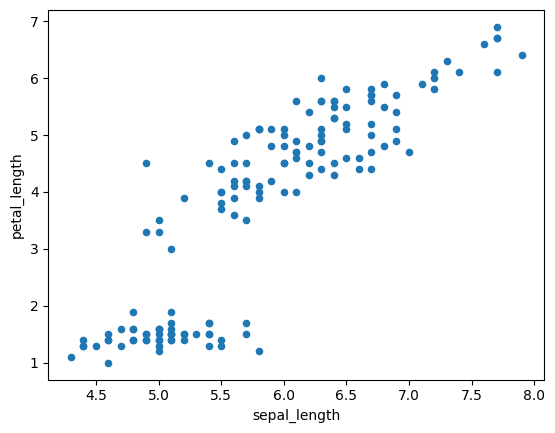

In [17]:
# scatter - needs x and y. Shows the relationship between two columns
df_iris.plot.scatter(x='sepal_length', y='petal_length')
plt.show()

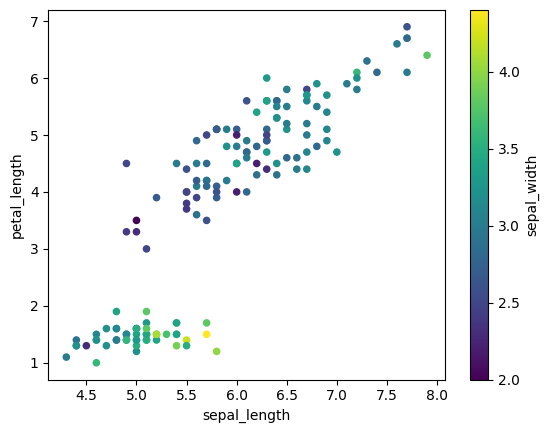

In [18]:
# c='column' - colour the dots by a third column (adds a colour bar)
df_iris.plot.scatter(x='sepal_length', y='petal_length', c='sepal_width')
plt.show()

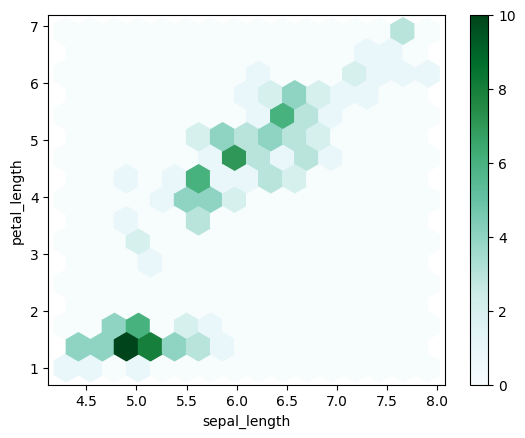

In [19]:
# hexbin - bins points into hexagons, better when there are too many points
df_iris.plot.hexbin(x='sepal_length', y='petal_length', gridsize=15)
plt.show()

### Pie Charts
A pie chart shows parts of a whole, where each slice is a share of the total. It works on a single Series, one slice per index entry. For one flower row the slices are the four measurements.

Pie charts are best with only a few categories. With many slices they get hard to read, and a bar chart is usually clearer.

`df.head(3).T` transposes the data (`.T` swaps rows and columns), so the 3 flowers become 3 columns. Then `subplots=True` draws one pie per column. `autopct='%.2f'` prints the percentage on each slice to 2 decimals.

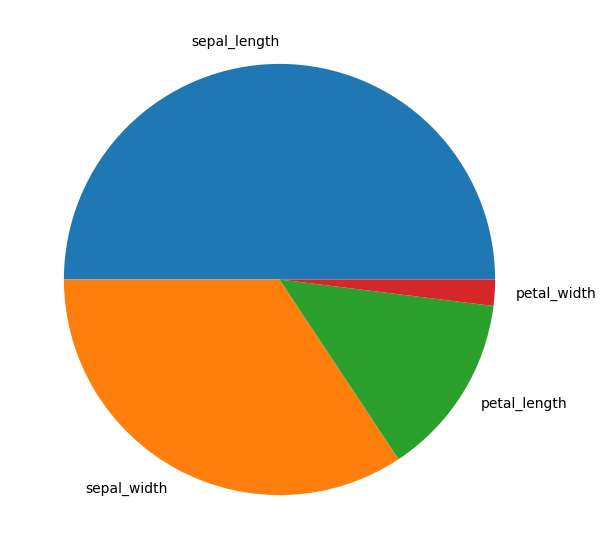

In [20]:
# pie - works on a single row. One slice per measurement
df_iris.iloc[0].plot.pie(figsize=(7, 7))
plt.show()

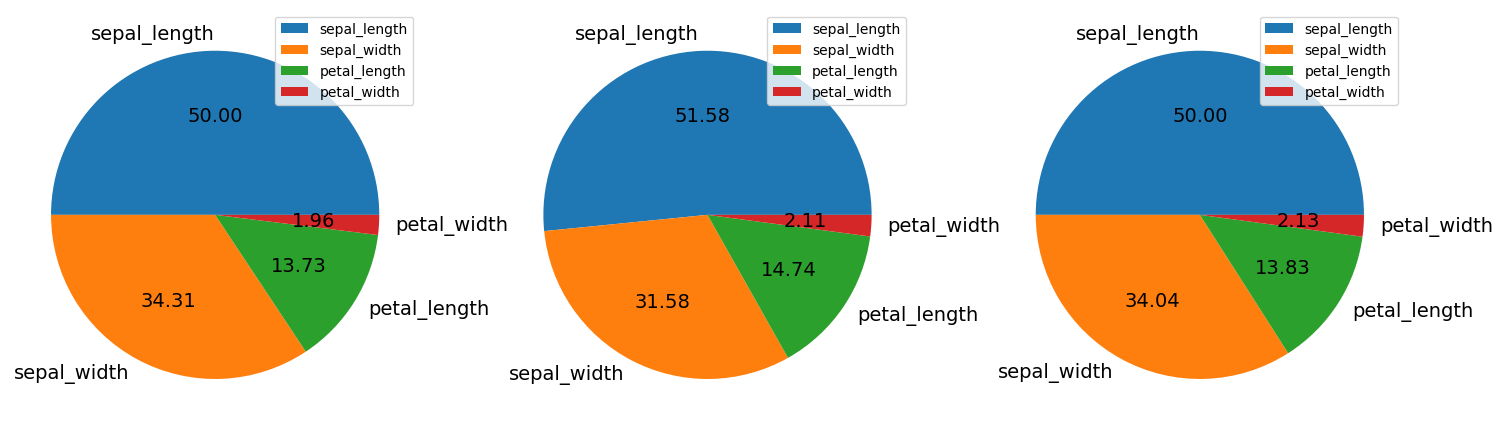

In [21]:
# T - transpose (rows become columns). subplots=True draws one pie per column
d3 = df_iris.head(3).T
d3.plot.pie(subplots=True, figsize=(18, 6), fontsize=14, autopct='%.2f')
plt.show()

### Built in Plots
pandas ships a few higher level plots in `pandas.plotting` for exploring a whole dataset at once:

- `scatter_matrix` draws every column against every other column in a grid, so I can scan all pairwise relationships in one view. `diagonal='kde'` puts a smooth density curve on the diagonal (where a column would just plot against itself).
- `.plot.kde()` is a Kernel Density Estimate, a smoothed version of a histogram. Instead of bars it draws a smooth curve of where values are dense.
- `andrews_curves` turns each row into a wavy curve and colours it by a class column. If the classes form separate bands of curves, it means the features separate the classes well, which is useful before building a classifier.

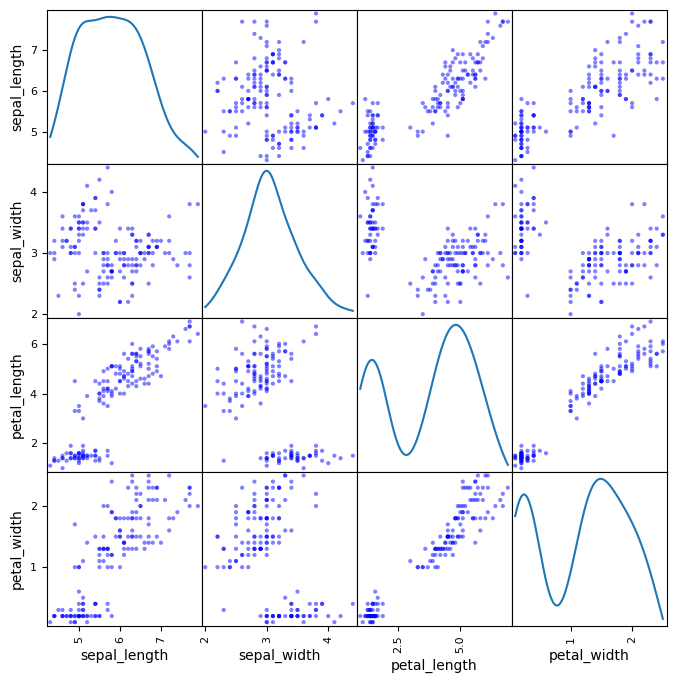

In [22]:
# scatter_matrix - every column vs every other. Diagonal shows each column's density
from pandas.plotting import scatter_matrix
scatter_matrix(df_iris, figsize=(8, 8), diagonal='kde', color='b')
plt.show()

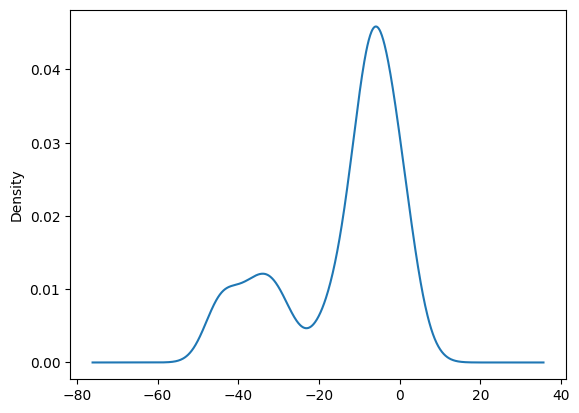

In [23]:
# kde - Kernel Density Estimate, a smoothed histogram
ts.plot.kde()
plt.show()

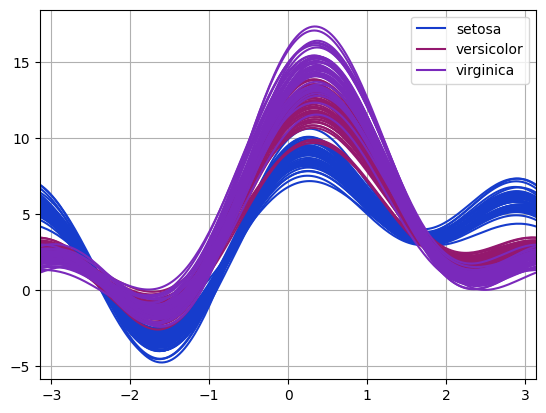

In [24]:
# andrews_curves - each row becomes a curve, coloured by class, to see separation
from pandas.plotting import andrews_curves
andrews_curves(iris, 'species')
plt.show()

### Plot Styling
Small arguments make a chart readable and presentation ready:

- `style='r--'` sets the line style. The letter is the colour (r = red) and the symbols are the line type (`--` = dashed).
- `legend=True` shows the legend that maps colours to labels.
- `logy=True` puts the y axis on a log scale, useful when values span many orders of magnitude.
- `secondary_y=True` plots a second set of columns against a separate y axis on the right. This is the fix when two columns live on very different scales and one would otherwise flatten the other.
- `subplots=True` with `layout=(rows, cols)` splits each column into its own small panel. `plt.tight_layout()` spaces them so labels do not overlap.

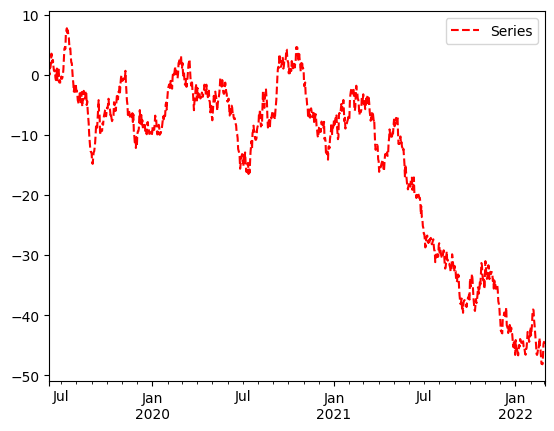

In [25]:
# style='r--' red dashed line, legend shows the label
ts.plot(style='r--', label='Series', legend=True)
plt.show()

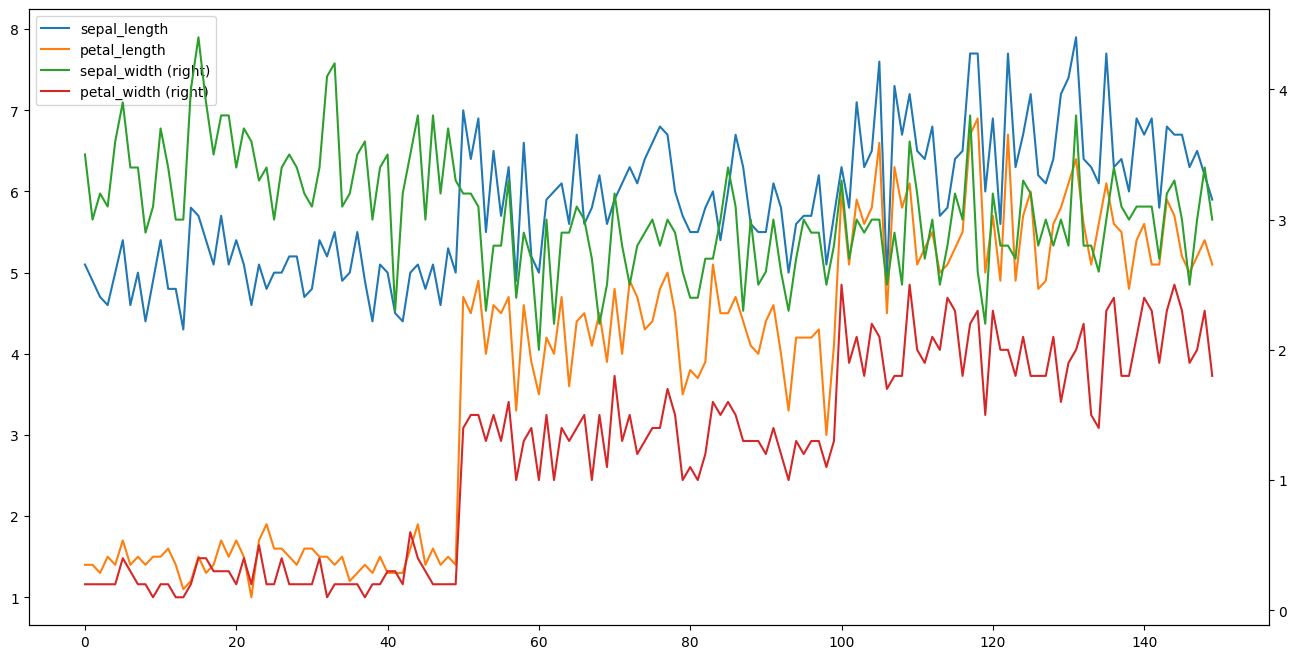

In [26]:
# secondary_y - plot a second set of columns on a right hand y axis (different scale)
x = df_iris[['sepal_length', 'petal_length']]
y = df_iris[['sepal_width', 'petal_width']]
ax = x.plot()
y.plot(figsize=(16, 8), secondary_y=True, ax=ax)
plt.show()

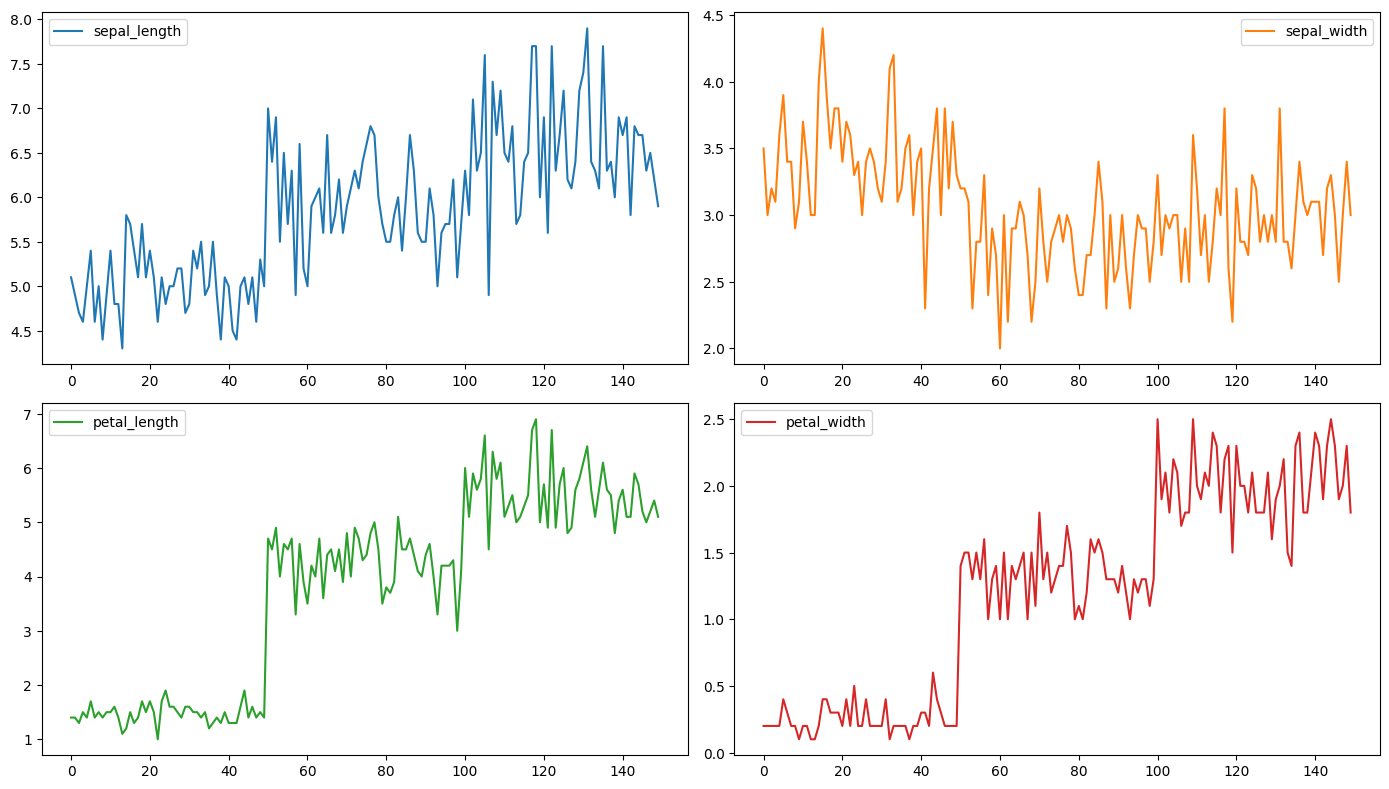

In [27]:
# subplots + layout - split each column into its own small plot
df_iris.plot(subplots=True, sharex=False, layout=(2, 2), figsize=(14, 8))
plt.tight_layout()
plt.show()

### Recap
- `.plot()` defaults to a line, switch with `kind=` or `.plot.<type>()`
- line for ordered/time data, bar for category comparison, hist for one variable's distribution, scatter for relationships, pie for parts of a whole
- `c=` encodes a third variable by colour, hexbin handles too many points
- scatter_matrix, kde and andrews_curves explore a whole dataset at once
- styling: `style`, `legend`, `logy`, `secondary_y`, `subplots` + `layout`